# VISUALIZING THE VECTORS & EMBEDDINGS IN 2D SPACE

* Reduce the vectors to 2 componenets with the variance reduction using PCA.     
* Plot the vectors with the scatter plot to compare with each other with and withoout custom word removal.

In [1]:
import os 
import sys
import numpy as np
import pandas as pd 
import scipy.sparse
from pathlib import Path

In [2]:
def find_root():
    cwd = Path.cwd()
    core_name = "EMATM0067_2025_TB-2-g43"
    
    for path in [cwd] + list(cwd.parents):
        if path.name.startswith(core_name):
            return path
            
    for path in cwd.rglob(f"{core_name}*"):
        if path.is_dir():
            return path
            
    return cwd

root_path = find_root()

# Convert to absolute path for reliability
root_path = root_path.resolve()

if str(root_path) not in sys.path:
    sys.path.insert(0, str(root_path))

# Switch to the project root
os.chdir(root_path)

reports_dir = root_path / 'reports'
figures_dir = reports_dir / 'figures'
tables_dir = reports_dir / 'tables'

# Create folders if they don't exist
figures_dir.mkdir(parents=True, exist_ok=True)
tables_dir.mkdir(parents=True, exist_ok=True)

data_file = root_path / 'data' / 'raw' / 'customer_support_tickets.csv'

if data_file.exists():
    print("PROJECT INITIALIZATION SUCCESSFUL")
    print(f"Project Root: {root_path}")
    print(f"Data Source: {data_file}")
    print(f"Figures will be saved to:\n {figures_dir}")
    print(f"Tables will be saved to:\n {tables_dir}")
else:
    print(f"ERROR: Data file not found at:\n {data_file}")
    print("Please ensure the 'data/raw' folder exists inside the project directory.")

PROJECT INITIALIZATION SUCCESSFUL
Project Root: E:\Study\Bristol\IATA\Group_Project\Final\EMATM0067_2025_TB-2-g43
Data Source: E:\Study\Bristol\IATA\Group_Project\Final\EMATM0067_2025_TB-2-g43\data\raw\customer_support_tickets.csv
Figures will be saved to:
 E:\Study\Bristol\IATA\Group_Project\Final\EMATM0067_2025_TB-2-g43\reports\figures
Tables will be saved to:
 E:\Study\Bristol\IATA\Group_Project\Final\EMATM0067_2025_TB-2-g43\reports\tables


In [3]:
# Import the necessary modules 
from src.evaluation.visualization import compare_representations

In [4]:
# Define the data directory relative to the root
data_dir = os.path.join(root_path, 'data', 'processed')
source_data_dir = os.path.join(root_path, 'data', 'raw')
file_name = 'customer_support_tickets.csv' 
file_path = os.path.join(source_data_dir, file_name)

# load the dataframe
df = pd.read_csv(file_path)
print(df.head())

# 1. Bag of Words
bow_path = os.path.join(data_dir, 'bow_vectors.npz')
bow_data = scipy.sparse.load_npz(bow_path)
print(f"Successfully loaded BoW from: {bow_path}")

# 2. TF-IDF
tfidf_path = os.path.join(data_dir, 'tfidf_vectors.npz')
tfidf_data = scipy.sparse.load_npz(tfidf_path)
print(f"Successfully loaded TF-IDF from: {tfidf_path}")

# 3. Skipgram
skipgram_path = os.path.join(data_dir, 'skipgram_embeddings.npy')
skipgram_embeddings = np.load(skipgram_path)
print(f"Successfully loaded Skipgram from: {skipgram_path}")

# 4. SBERT
sbert_path = os.path.join(data_dir, 'sbert_embeddings.npy')
sbert_embeddings = np.load(sbert_path)
print(f"Successfully loaded SBERT from: {sbert_path}")

   Ticket ID        Customer Name              Customer Email  Customer Age  \
0          1        Marisa Obrien  carrollallison@example.com            32   
1          2         Jessica Rios    clarkeashley@example.com            42   
2          3  Christopher Robbins   gonzalestracy@example.com            48   
3          4     Christina Dillon    bradleyolson@example.org            27   
4          5    Alexander Carroll     bradleymark@example.com            67   

  Customer Gender Product Purchased Date of Purchase      Ticket Type  \
0           Other        GoPro Hero       2021-03-22  Technical issue   
1          Female       LG Smart TV       2021-05-22  Technical issue   
2           Other          Dell XPS       2020-07-14  Technical issue   
3          Female  Microsoft Office       2020-11-13  Billing inquiry   
4          Female  Autodesk AutoCAD       2020-02-04  Billing inquiry   

             Ticket Subject  \
0             Product setup   
1  Peripheral compatibil

PCA — Explained variance: PC1=0.0514, PC2=0.0412, Total=0.0926
PCA — Explained variance: PC1=0.0272, PC2=0.0246, Total=0.0518
PCA — Explained variance: PC1=0.0974, PC2=0.0699, Total=0.1673
PCA — Explained variance: PC1=0.1541, PC2=0.0630, Total=0.2172


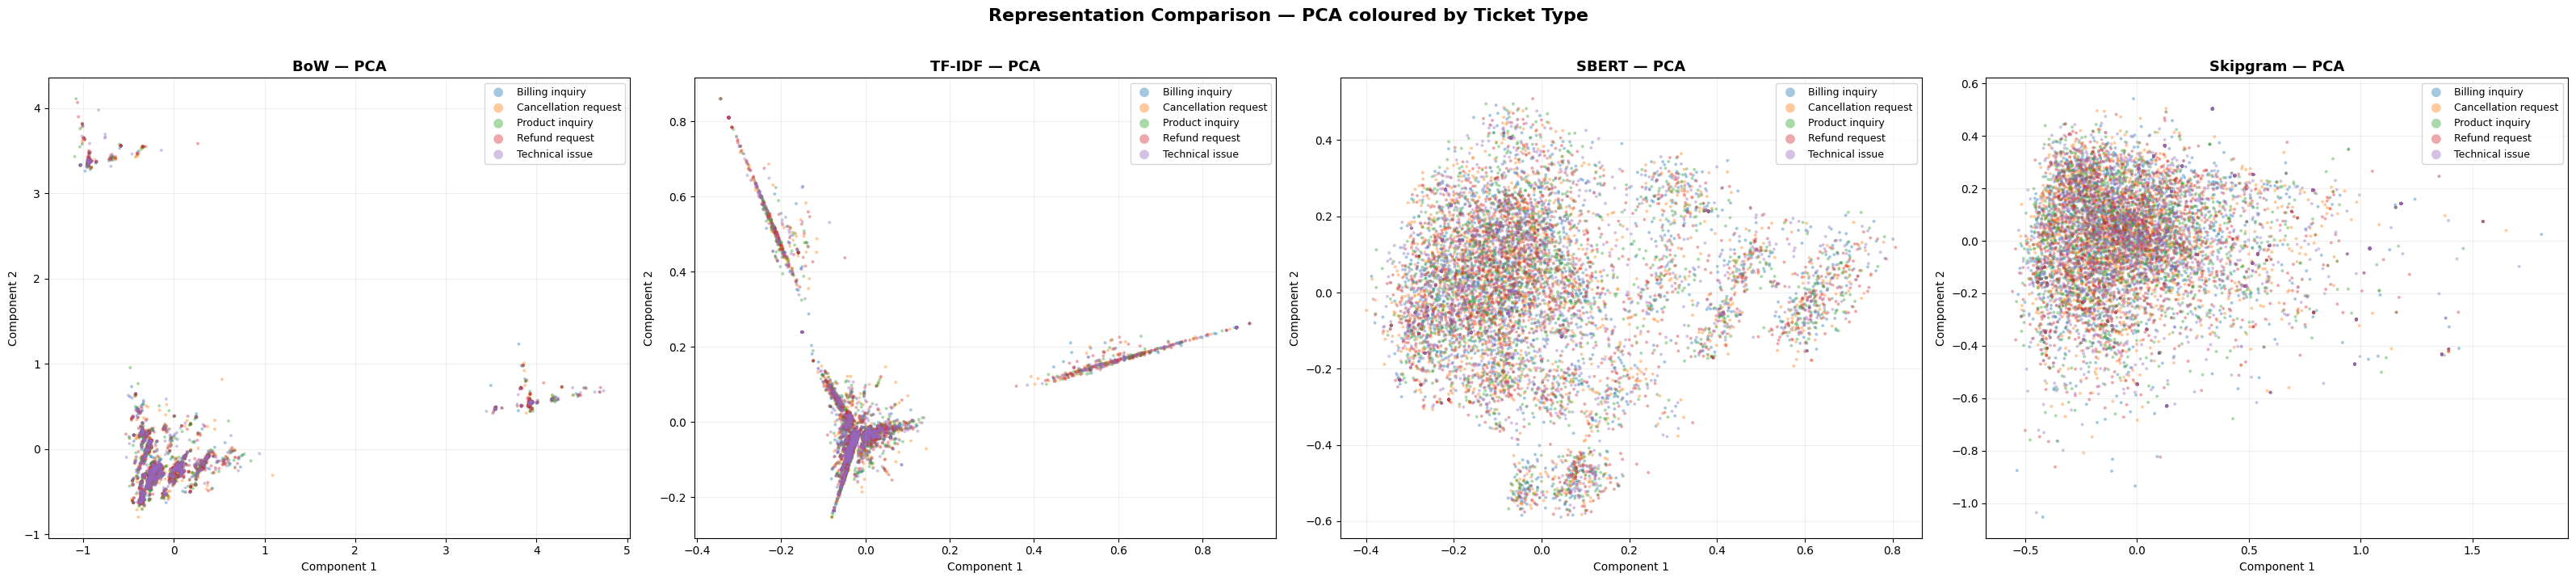

In [5]:
# Compare visualization with ticket type 
compare_representations(
    X_bow = bow_data, 
    X_tfidf = tfidf_data, 
    X_sbert = sbert_embeddings, 
    X_skipgram = skipgram_embeddings,
    df = df,
    label_col = 'Ticket Type',
    save_path = os.path.join(figures_dir, 'representation_comparison_pca_coloured_by_ticket_type.png')
    )

### Scatter Plot of vector/Embeddings with Ticket Type

* BoW
    - The Bag of Words (BoW) forms the count of the each word tokens in the document which forms a dense central cluster surrounded by the sparse outliers. It won't capture the semantic meaning out of it.
    - From the visuals, it infers most tickets shares common words and cluster tightly, so the unique words of the tickets reflects as the outliers, which leads to the no separation between the tickets types based on the unique words leading to no clear visible cluster separation based on ticket types.   

* TF-IDF
    - TF-IDF calculates the frequency of words in each document and occurrences of words in other documents, which makes the uniqueness of specific words for the documents. TF-IDF didn't capture the sematic relationship between the tokens. 
    - From the visuals, it produces a spike star pattern radiating from a dense central cluster, which implies the most frequent common corpus-wide terms cluster near the origin with near-zero TF-IDF weights, and unique terms for each ticket produce spikes outward, each direction representing a dominant term. 
    - But there is no separation between the ticket types based on the unique words, leading to no clear visible cluster separation based on ticket types.   
* SBERT
    - SBERT captures the semantics by compressing an entire sentence into a single embedding and projects it in the vector space.
    - From the visuals, it infers the compressed ticket descriptions cause most embeddings to collapse into a dense central region since most of the sentences have the same template dominating the sentence-level representation. 
    - This shows the ticket description embeddings have high semantic similarity, which makes SBERT insufficient for distinguishing based on ticket issue types. 

* Skipgram
    - Skipgram embeddings capture the semantics of the words in the embedding space with the cosine similarity, by predicting surrounding context words.
    - From the visuals, it infers averaging word vectors across the document loses positional and contextual relationships, reducing discriminative power.
    - This shows the word embeddings have high semantic similarity, which makes skipgram insufficient for distinguishing based on ticket issue types.

PCA — Explained variance: PC1=0.0514, PC2=0.0412, Total=0.0926
PCA — Explained variance: PC1=0.0272, PC2=0.0246, Total=0.0518
PCA — Explained variance: PC1=0.0974, PC2=0.0699, Total=0.1673
PCA — Explained variance: PC1=0.1541, PC2=0.0630, Total=0.2172


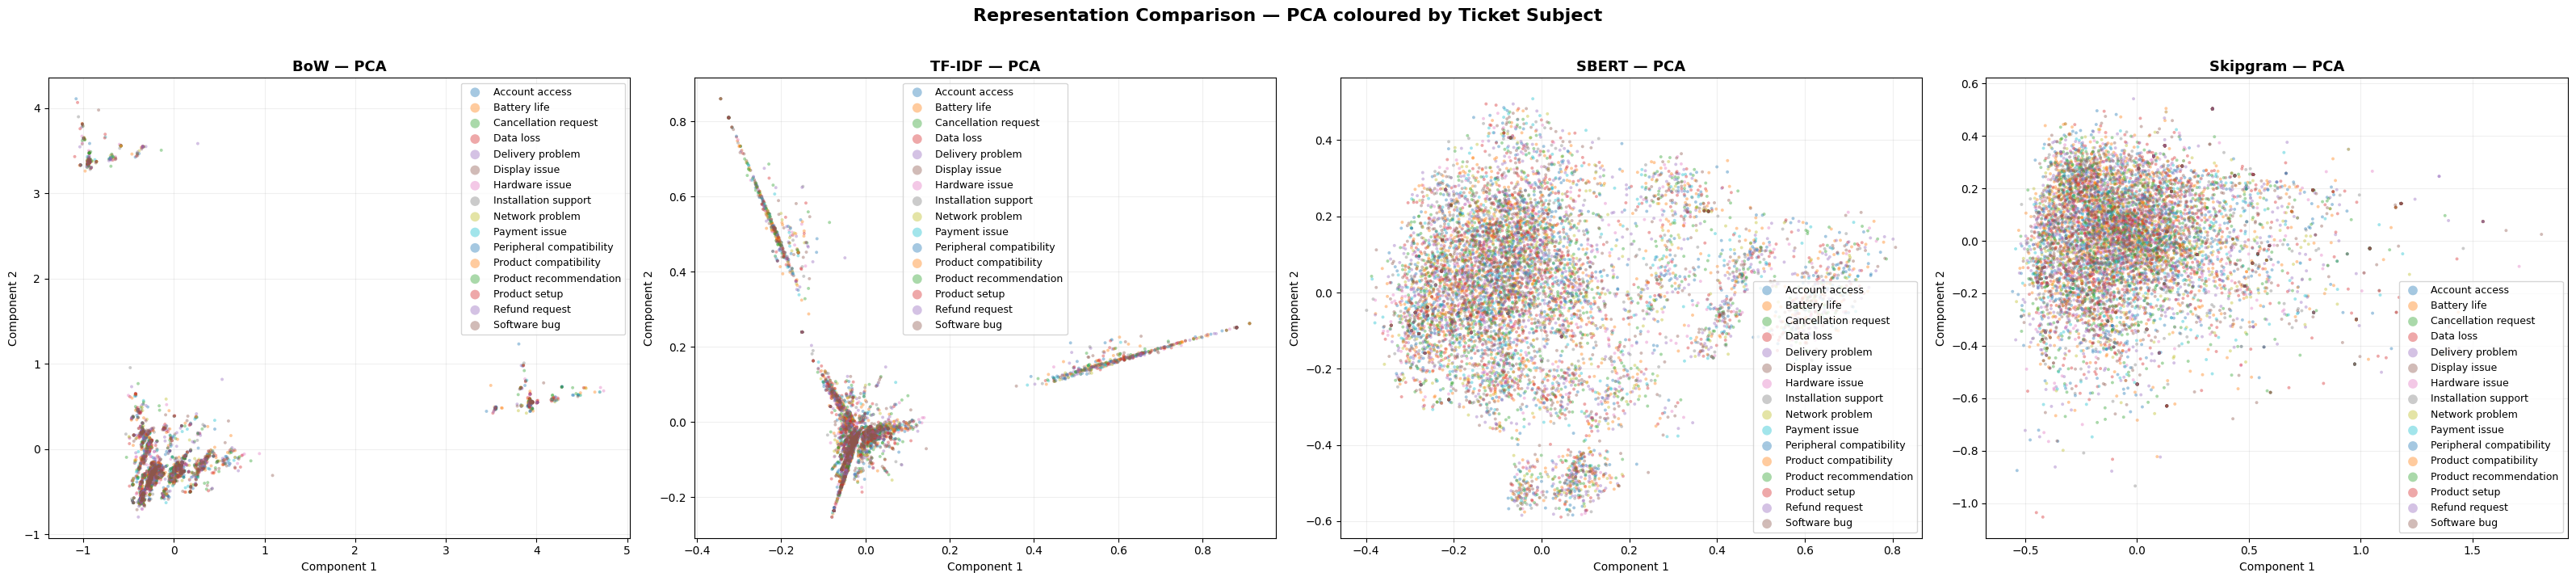

In [6]:
# Compare visualization with ticket subject
compare_representations(
    X_bow = bow_data, 
    X_tfidf = tfidf_data, 
    X_sbert = sbert_embeddings, 
    X_skipgram = skipgram_embeddings,
    df = df,
    label_col='Ticket Subject',
    save_path = os.path.join(figures_dir, 'representation_comparison_pca_coloured_by_ticket_subject.png')
    )

### Scatter Plot of vector/Embeddings with Ticket Type

* BoW
    - The Bag of Words (BoW) forms the count of the each word tokens in the document which forms a dense central cluster surrounded by the sparse outliers. It won't capture the semantic meaning out of it.
    - From the visuals, it infers most tickets shares common words and cluster tightly, so the unique words of the tickets reflects as the outliers, which leads to the no separation between the tickets types based on the unique words leading to no clear visible cluster separation based on ticket subjects.   

* TF-IDF
    - TF-IDF calculates the frequency of words in each document and occurrences of words in other documents, which makes the uniqueness of specific words for the documents. TF-IDF didn't capture the sematic relationship between the tokens. 
    - From the visuals, it produces a spike star pattern radiating from a dense central cluster, which implies the most frequent common corpus-wide terms cluster near the origin with near-zero TF-IDF weights, and unique terms for each ticket produce spikes outward, each direction representing a dominant term. 
    - But there is no separation between the ticket types based on the unique words, leading to no clear visible cluster separation based on ticket subjects.   
* SBERT
    - SBERT captures the semantics by compressing an entire sentence into a single embedding and projects it in the vector space.
    - From the visuals, it infers the compressed ticket descriptions cause most embeddings to collapse into a dense central region since most of the sentences have the same template dominating the sentence-level representation. 
    - This shows the ticket description embeddings have high semantic similarity, which makes SBERT insufficient for distinguishing based on ticket subjects. 

* Skipgram
    - Skipgram embeddings capture the semantics of the words in the embedding space with the cosine similarity, by predicting surrounding context words.
    - From the visuals, it infers averaging word vectors across the document loses positional and contextual relationships, reducing discriminative power.
    - This shows the word embeddings have high semantic similarity, which makes skipgram insufficient for distinguishing based on ticket subject. 
